# HW2.5 — GPU Assignment I (Pandas-Free)

This notebook is for the lab Docker environment and avoids `pandas`.

It uses:
- Python standard library
- NumPy
- Matplotlib
- PyTorch

All outputs are saved under `/app`.


## Part A — GPU Onboarding and Provenance

The experiments were performed on an **NVIDIA GeForce RTX 4090**.

The GPU and software environment used for the measurements were:

- **GPU:** NVIDIA GeForce RTX 4090
- **GPU UUID:** `GPU-3094e1cd-3205-910b-9555-93d8401b1ce0`
- **Driver Version:** 610.60
- **VRAM:** 24,564 MiB
- **Reported Power Limit:** 450 W
- **PyTorch Version:** 2.1.2
- **CUDA Version used by PyTorch:** 12.1
- **cuDNN Version:** 8902

The complete `nvidia-smi -q` output was saved to:

`results/gpu_info/nvidia_smi_q.txt`

The software and hardware summary was also saved to:

`results/gpu_info/software_stack.txt`

These files provide provenance for the benchmark results and allow each measurement to be traced back to the specific GPU UUID used during the experiment.

In [16]:
import sys
print(sys.executable)

/opt/conda/bin/python


In [17]:
import sys
!{sys.executable} -m pip install pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.0/125.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 14.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 14.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 14.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.5/347.5 kB 11.1 MB/s eta 0:00:00


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)

NumPy: 1.26.2
Pandas: 2.3.3
PyTorch: 2.1.2


### Environment and Library Setup

The notebook first identifies the Python interpreter being used inside the Docker environment and installs the required Python libraries for data handling and plotting.

The main libraries used in the notebook are:

- **NumPy** for numerical calculations
- **Pandas** for tabular data handling
- **Matplotlib** for plotting benchmark results
- **PyTorch** for GPU tensor operations and CUDA benchmarking

The notebook also verifies the installed library versions to document the software environment used for the experiments.

In [2]:
from pathlib import Path
import csv, math, time, subprocess, threading
from datetime import datetime
import numpy as np
#import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

ROOT = Path("/app")
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"
GPU_INFO_DIR = RESULTS / "gpu_info"
MATMUL_DIR = RESULTS / "matmul"
BANDWIDTH_DIR = RESULTS / "bandwidth"
ATTN_DIR = RESULTS / "attention"
THERMAL_DIR = RESULTS / "thermal"

for p in [GPU_INFO_DIR, MATMUL_DIR, BANDWIDTH_DIR, ATTN_DIR, THERMAL_DIR, FIGURES]:
    p.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


PyTorch: 2.1.2
CUDA: 12.1
CUDA available: True
GPU: NVIDIA GeForce RTX 4090


### Output Directory Setup

The notebook defines `/app` as the main working directory inside the Docker container.

Separate folders are created for:

- GPU system information
- Matrix multiplication results
- Memory-bandwidth results
- Attention benchmarks
- Thermal measurements
- Figures

This organization keeps the benchmark outputs separated by experiment and ensures that the generated CSV files, logs, and plots can be easily located for submission.

In [4]:
def save_rows_csv(path, rows):
    rows = list(rows)
    if not rows:
        return
    fieldnames = []
    for row in rows:
        for key in row:
            if key not in fieldnames:
                fieldnames.append(key)
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

def show_rows(rows):
    for row in rows:
        print(row)


### Result-Saving Helper Functions

The `save_rows_csv()` function saves benchmark results stored as dictionaries into CSV files. It automatically determines the column names from the dictionary keys and writes the rows to disk.

The `show_rows()` function prints each result dictionary to the notebook output. These helper functions are reused throughout the notebook so that experimental measurements can be both displayed and saved consistently.

## Configuration

In [5]:
THEORETICAL_TFLOPS = {"FP32": None, "TF32": None, "FP16": None, "BF16": None}
MATRIX_SIZES = [1024, 4096, 8192, 16384]
WARMUP_REPS = 10
TIMED_REPS = 30

ATTN_DTYPE = torch.float16
ATTN_BATCH = 8
ATTN_HEADS = 1
ATTN_HEAD_DIM = 64
ATTN_SEQ_LENGTHS = [512, 1024, 2048, 4096, 8192, 16384]


### Benchmark Configuration

The matrix-multiplication benchmarks use square matrices with dimensions:

- 1024
- 4096
- 8192
- 16384

Each matrix multiplication is warmed up for **10 iterations** and then measured for **30 timed iterations**.

The attention experiments use:

- FP16 precision
- Batch size = 8
- Number of heads = 1
- Head dimension = 64
- Sequence lengths from 512 to 16,384

These values remain fixed across the attention experiments so that the naive and fused implementations can be compared under the same conditions.

## Part A — Provenance

In [6]:
assert torch.cuda.is_available()

raw = subprocess.check_output([
    "nvidia-smi",
    "--query-gpu=name,uuid,driver_version,memory.total,power.limit",
    "--format=csv,noheader,nounits"
], text=True).strip()

parts = [x.strip() for x in raw.split(",")]
gpu_record = {
    "name": parts[0],
    "uuid": parts[1],
    "driver_version": parts[2],
    "memory_total_mib": parts[3],
    "power_limit_w": parts[4],
    "pytorch_version": torch.__version__,
    "pytorch_cuda_version": torch.version.cuda,
    "cudnn_version": torch.backends.cudnn.version(),
}
show_rows([gpu_record])


{'name': 'NVIDIA GeForce RTX 4090', 'uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'driver_version': '610.60', 'memory_total_mib': '24564', 'power_limit_w': '450.00', 'pytorch_version': '2.1.2', 'pytorch_cuda_version': '12.1', 'cudnn_version': 8902}


### GPU Hardware and Software Identification

The notebook uses `nvidia-smi` to query the GPU name, UUID, driver version, total GPU memory, and configured power limit.

PyTorch is also used to record:

- PyTorch version
- CUDA version used by PyTorch
- cuDNN version

The GPU UUID is stored with the benchmark results so that all measurements can be traced to the exact GPU used during the experiment.

In [7]:
with open(GPU_INFO_DIR / "nvidia_smi_q.txt", "w", encoding="utf-8") as f:
    subprocess.run(["nvidia-smi", "-q"], stdout=f, text=True, check=True)

with open(GPU_INFO_DIR / "software_stack.txt", "w", encoding="utf-8") as f:
    for k, v in gpu_record.items():
        f.write(f"{k}: {v}\n")
print("Saved Part A files.")


Saved Part A files.


### Provenance Files

The complete output of `nvidia-smi -q` is saved to `nvidia_smi_q.txt`.

A shorter software and hardware summary is saved separately in `software_stack.txt`.

These files provide a permanent record of the hardware and software configuration under which the benchmark measurements were collected.

## Part B — Matmul throughput

## Part B — Precision and Achieved Throughput

Dense square matrix multiplication was benchmarked at matrix sizes:

`N = 1024, 4096, 8192, 16384`

The tested numerical precisions were:

- FP32
- TF32
- FP16
- BF16

For an `N × N` matrix multiplication, the approximate computational cost is:

\[
2N^3 \text{ FLOPs}
\]

Achieved throughput was calculated as:

\[
\text{TFLOPS} =
\frac{2N^3}
{\text{execution time in seconds} \times 10^{12}}
\]

CUDA events were used for timing because GPU operations are asynchronous. Each configuration was warmed up before measurement and then timed repeatedly to reduce timing variance.

In [9]:
def benchmark_matmul_one(n, precision, warmups=WARMUP_REPS, reps=TIMED_REPS):
    torch.cuda.empty_cache()
    if precision == "FP32":
        dtype = torch.float32
        torch.set_float32_matmul_precision("highest")
    elif precision == "TF32":
        dtype = torch.float32
        torch.set_float32_matmul_precision("high")
    elif precision == "FP16":
        dtype = torch.float16
    elif precision == "BF16":
        dtype = torch.bfloat16
    else:
        raise ValueError(precision)

    a = torch.randn((n, n), device="cuda", dtype=dtype)
    b = torch.randn((n, n), device="cuda", dtype=dtype)

    for _ in range(warmups):
        c = a @ b
    torch.cuda.synchronize()

    times = []
    for _ in range(reps):
        s = torch.cuda.Event(enable_timing=True)
        e = torch.cuda.Event(enable_timing=True)
        s.record()
        c = a @ b
        e.record()
        torch.cuda.synchronize()
        times.append(s.elapsed_time(e))

    mean_ms = float(np.mean(times))
    sec = mean_ms / 1000.0
    tflops = (2.0 * n**3) / sec / 1e12
    theo = THEORETICAL_TFLOPS.get(precision)
    pct = None if theo in (None, 0) else 100.0 * tflops / theo

    del a, b, c
    torch.cuda.empty_cache()

    return {
        "gpu_uuid": gpu_record["uuid"], "precision": precision, "N": n,
        "warmup_reps": warmups, "timed_reps": reps,
        "mean_ms": mean_ms, "std_ms": float(np.std(times, ddof=1)),
        "achieved_tflops": tflops, "theoretical_tflops": theo,
        "percent_theoretical": pct, "status": "SUCCESS"
    }


### Matrix Multiplication Benchmark Function

The `benchmark_matmul_one()` function is used to measure how fast the GPU performs square matrix multiplication for different matrix sizes and precision types.

In this experiment, I tested four precision modes:

- FP32
- TF32
- FP16
- BF16

For FP32 and TF32, the PyTorch matrix-multiplication precision setting is used to control how the operation is executed. FP16 and BF16 use their corresponding PyTorch data types directly.

For each test, two random matrices of size `N × N` are created directly on the GPU. Before measuring the execution time, the code performs several warm-up matrix multiplications. This helps reduce the effect of initialization and startup overhead on the final timing result.

CUDA events are used to measure the execution time because GPU operations are asynchronous and normal CPU timing would not accurately represent the GPU execution time.

For an `N × N` matrix multiplication, the approximate number of floating-point operations is:

$$
2N^3
$$

Using the measured execution time, the achieved GPU performance is calculated as:

$$
\text{TFLOPS}
=
\frac{2N^3}
{\text{execution time in seconds} \times 10^{12}}
$$

The function finally records the matrix size, precision type, average execution time, timing variation, achieved TFLOPS, GPU UUID, and whether the operation completed successfully.

In [10]:
matmul_rows = []
for precision in ["FP32", "TF32", "FP16", "BF16"]:
    for n in MATRIX_SIZES:
        print(f"Running {precision}, N={n}")
        try:
            row = benchmark_matmul_one(n, precision)
        except torch.OutOfMemoryError:
            torch.cuda.empty_cache()
            row = {"gpu_uuid": gpu_record["uuid"], "precision": precision, "N": n, "status": "OOM"}
        matmul_rows.append(row)
        print(row)

save_rows_csv(MATMUL_DIR / "matmul_results.csv", matmul_rows)


Running FP32, N=1024
{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'precision': 'FP32', 'N': 1024, 'warmup_reps': 10, 'timed_reps': 30, 'mean_ms': 0.061412267138560614, 'std_ms': 0.00910279456286677, 'achieved_tflops': 34.968317374682954, 'theoretical_tflops': None, 'percent_theoretical': None, 'status': 'SUCCESS'}
Running FP32, N=4096
{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'precision': 'FP32', 'N': 4096, 'warmup_reps': 10, 'timed_reps': 30, 'mean_ms': 2.546283745765686, 'std_ms': 0.12212032092790735, 'achieved_tflops': 53.97629140921649, 'theoretical_tflops': None, 'percent_theoretical': None, 'status': 'SUCCESS'}
Running FP32, N=8192
{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'precision': 'FP32', 'N': 8192, 'warmup_reps': 10, 'timed_reps': 30, 'mean_ms': 20.625155194600424, 'std_ms': 0.1567939019471013, 'achieved_tflops': 53.30925354994891, 'theoretical_tflops': None, 'percent_theoretical': None, 'status': 'SUCCESS'}
Running FP32, N=16384
{'

### Matrix Multiplication Sweep

The benchmark is repeated for every combination of matrix size and numerical precision.

For each configuration, the notebook records whether the operation completed successfully or encountered an out-of-memory condition.

All measurements are stored in `matmul_results.csv`.

This sweep makes it possible to compare how matrix size and numerical precision affect GPU computational throughput.

In [11]:
!ls -lh /app/results/matmul/

total 4.0K
-rw-r--r-- 1 root root 2.1K Sep 16 00:22 matmul_results.csv


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch

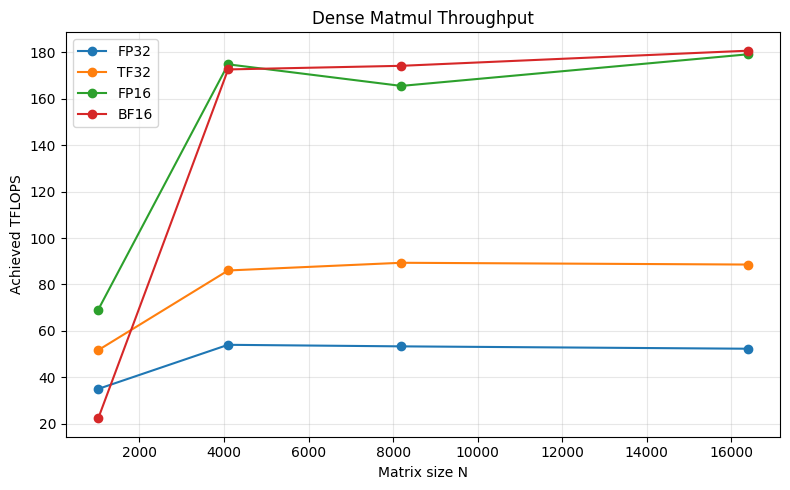

In [20]:
fig, ax = plt.subplots(figsize=(8,5))
for precision in ["FP32","TF32","FP16","BF16"]:
    pts = [r for r in matmul_rows if r.get("precision")==precision and r.get("status")=="SUCCESS"]
    if pts:
        ax.plot([r["N"] for r in pts],[r["achieved_tflops"] for r in pts],marker="o",label=precision)
ax.set_xlabel("Matrix size N")
ax.set_ylabel("Achieved TFLOPS")
ax.set_title("Dense Matmul Throughput")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "matmul_tflops.png", dpi=160)
plt.show()


### Matrix Multiplication Performance Plot

The plot compares achieved TFLOPS as matrix size increases for FP32, TF32, FP16, and BF16.

The smaller matrix sizes show lower throughput because there is less computation available to fully utilize the GPU.

As matrix size increases, the GPU reaches substantially higher throughput because more parallel work is available.

The reduced-precision FP16 and BF16 modes achieve the highest throughput in the experiment, while FP32 produces lower computational throughput.

## Part C — Bandwidth and arithmetic intensity

In [21]:
def benchmark_elementwise_add(num_elements=128_000_000, dtype=torch.float32, warmups=10, reps=30):
    a = torch.randn(num_elements, device="cuda", dtype=dtype)
    b = torch.randn(num_elements, device="cuda", dtype=dtype)
    for _ in range(warmups):
        c = a + b
    torch.cuda.synchronize()

    times=[]
    for _ in range(reps):
        s=torch.cuda.Event(enable_timing=True); e=torch.cuda.Event(enable_timing=True)
        s.record(); c=a+b; e.record(); torch.cuda.synchronize()
        times.append(s.elapsed_time(e))

    mean_ms=float(np.mean(times))
    sec=mean_ms/1000.0
    bytes_per_element=torch.tensor([],dtype=dtype).element_size()
    bytes_moved=num_elements*bytes_per_element*3
    gbps=bytes_moved/sec/1e9
    ai=num_elements/bytes_moved
    del a,b,c
    torch.cuda.empty_cache()
    return {"gpu_uuid":gpu_record["uuid"],"operation":"elementwise_add","mean_ms":mean_ms,
            "effective_bandwidth_gbs":gbps,"arithmetic_intensity_flops_per_byte":ai}

bw_row=benchmark_elementwise_add()
save_rows_csv(BANDWIDTH_DIR/"bandwidth_results.csv",[bw_row])
print(bw_row)


{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'operation': 'elementwise_add', 'mean_ms': 1.6828853408495585, 'effective_bandwidth_gbs': 912.7181529934728, 'arithmetic_intensity_flops_per_byte': 0.08333333333333333}


### Memory-Bandwidth Benchmark

The elementwise-add experiment is designed to represent a memory-intensive workload.

Two large FP32 vectors are created on the GPU and added together.

For every output element:

- one value is read from the first input
- one value is read from the second input
- one result is written

Because FP32 values require 4 bytes each, approximately 12 bytes of memory traffic are required per output element.

CUDA events are used to measure the execution time, and the effective memory bandwidth is calculated from the total estimated bytes transferred divided by execution time.

The arithmetic intensity is also calculated as the number of floating-point operations performed per byte transferred.

In [22]:
N_ROOFLINE=8192
matmul_ai=(2*N_ROOFLINE**3)/(3*N_ROOFLINE**2*4)
roofline_rows=[
    {"gpu_uuid":gpu_record["uuid"],"operation":"elementwise_add_fp32",
     "arithmetic_intensity_flops_per_byte":bw_row["arithmetic_intensity_flops_per_byte"],"expected_side":"memory-bound"},
    {"gpu_uuid":gpu_record["uuid"],"operation":f"matmul_fp32_N{N_ROOFLINE}",
     "arithmetic_intensity_flops_per_byte":matmul_ai,"expected_side":"compute-bound"}
]
save_rows_csv(BANDWIDTH_DIR/"arithmetic_intensity.csv",roofline_rows)
show_rows(roofline_rows)


{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'operation': 'elementwise_add_fp32', 'arithmetic_intensity_flops_per_byte': 0.08333333333333333, 'expected_side': 'memory-bound'}
{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'operation': 'matmul_fp32_N8192', 'arithmetic_intensity_flops_per_byte': 1365.3333333333333, 'expected_side': 'compute-bound'}


### Arithmetic Intensity Comparison

The elementwise-add operation has a very low arithmetic intensity because it performs only a small amount of computation while moving a relatively large amount of data to and from GPU memory.

Matrix multiplication is very different because the same matrix values are reused many times during multiply-and-add operations. Because of this, much more computation is performed for the amount of data being transferred.

For an `N × N` matrix multiplication, the approximate number of floating-point operations is:

$$
2N^3
$$

The notebook compares this computational work with the minimum amount of matrix data that needs to be transferred in order to estimate the arithmetic intensity.

From this comparison, elementwise addition behaves mainly as a **memory-bound operation**, while large matrix multiplication behaves more like a **compute-bound operation**.

## Part D — Naive and fused attention

## D1. Configuration

In [33]:
ATTN_BATCH = 8

ATTN_HEADS = 1

ATTN_HEAD_DIM = 64

ATTN_DTYPE = torch.float16

SEQ_LENGTHS = [
    512,
    1024,
    2048,
    4096,
    8192,
    16384
]

### Attention Benchmark Configuration

The attention experiments use a fixed configuration of:

- Batch size = 8
- One attention head
- Head dimension = 64
- FP16 precision

The sequence length is varied from 512 to 16,384 tokens.

Keeping the batch size, number of heads, head dimension, and precision fixed allows the effect of increasing sequence length to be studied directly.

## d2. Create Q, K, V

In [34]:
def create_qkv(L):

    shape = (
        ATTN_BATCH,
        ATTN_HEADS,
        L,
        ATTN_HEAD_DIM
    )

    Q = torch.randn(
        shape,
        device="cuda",
        dtype=ATTN_DTYPE
    )

    K = torch.randn(
        shape,
        device="cuda",
        dtype=ATTN_DTYPE
    )

    V = torch.randn(
        shape,
        device="cuda",
        dtype=ATTN_DTYPE
    )

    return Q, K, V

### Query, Key, and Value Tensor Creation

The `create_qkv()` function creates the Query (`Q`), Key (`K`), and Value (`V`) tensors required for the attention calculation.

Each tensor has the shape:

\[
(\text{batch},\text{heads},L,\text{head dimension})
\]

where \(L\) is the sequence length.

The tensors are generated directly on the GPU using FP16 precision.

## D3. Naive attention

In [35]:
def naive_attention(Q, K, V):

    scores = torch.matmul(
        Q,
        K.transpose(-2, -1)
    )

    scores = (
        scores /
        math.sqrt(
            Q.size(-1)
        )
    )

    probabilities = torch.softmax(
        scores,
        dim=-1
    )

    output = torch.matmul(
        probabilities,
        V
    )

    return output

### Naive Scaled Dot-Product Attention

The naive attention implementation calculates attention step by step using the Query, Key, and Value tensors.

First, the Query tensor is multiplied by the transpose of the Key tensor:

$$
QK^T
$$

This produces the attention-score matrix. If the sequence length is `L`, the score matrix has dimensions:

$$
L \times L
$$

The scores are then scaled by dividing them by:

$$
\sqrt{d}
$$

where `d` is the head dimension.

After that, softmax is applied to convert the scores into attention probabilities. These probabilities are then multiplied by the Value tensor to produce the final attention output.

The main memory issue with this naive approach is that it creates the full `L × L` score matrix and probability matrix in memory. Because of this, the memory usage increases very quickly as the sequence length becomes larger, approximately following quadratic growth with respect to `L`.

## D4. Fused attention

In [36]:
def fused_attention(Q, K, V):

    return F.scaled_dot_product_attention(
        Q,
        K,
        V
    )

### Fused Attention

The fused implementation uses PyTorch's `scaled_dot_product_attention()` function.

The function performs the scaled dot-product attention operation directly from the Query, Key, and Value tensors.

Unlike the explicit naive implementation, the notebook does not manually create the score matrix and probability matrix in separate Python operations.

This implementation is benchmarked against the naive version using the same input dimensions and precision.

## D5. Benchmark function

In [37]:
def benchmark_attention(
    L,
    implementation,
    warmups=3,
    reps=10
):

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()

    Q, K, V = create_qkv(L)

    if implementation == "naive":

        function = naive_attention

    else:

        function = fused_attention

    try:

        for _ in range(warmups):

            output = function(
                Q, K, V
            )

        torch.cuda.synchronize()

        torch.cuda.reset_peak_memory_stats()

        times = []

        for _ in range(reps):

            start = torch.cuda.Event(
                enable_timing=True
            )

            end = torch.cuda.Event(
                enable_timing=True
            )

            start.record()

            output = function(
                Q, K, V
            )

            end.record()

            torch.cuda.synchronize()

            times.append(
                start.elapsed_time(end)
            )

        peak_bytes = (
            torch.cuda
            .max_memory_allocated()
        )

        result = {

            "gpu_uuid":
                gpu_record["gpu_uuid"],

            "implementation":
                implementation,

            "sequence_length":
                L,

            "batch":
                ATTN_BATCH,

            "head_dim":
                ATTN_HEAD_DIM,

            "mean_ms":
                float(np.mean(times)),

            "peak_memory_gib":
                float(
                    peak_bytes /
                    1024**3
                ),

            "status":
                "SUCCESS"
        }

        del Q, K, V, output

        torch.cuda.empty_cache()

        return result

    except torch.OutOfMemoryError:

        torch.cuda.empty_cache()

        return {

            "gpu_uuid":
                gpu_record["gpu_uuid"],

            "implementation":
                implementation,

            "sequence_length":
                L,

            "status":
                "OOM"
        }

### Attention Benchmarking Method

The attention benchmark function measures both execution latency and peak GPU memory usage.

Before each benchmark, the CUDA cache is cleared and PyTorch's peak-memory statistics are reset.

The selected attention implementation is warmed up before timing begins.

CUDA events are then used to measure forward-pass execution time over multiple repetitions.

Peak allocated GPU memory is collected using PyTorch's CUDA memory statistics.

For every sequence length, the benchmark records:

- sequence length
- implementation type
- mean latency
- timing variation
- peak allocated GPU memory
- execution status
- GPU UUID

## D6. Naive coarse sweep

In [39]:
naive_rows=[]
for L in ATTN_SEQ_LENGTHS:
    print("Naive",L)
    row=benchmark_attention_one(L,"naive")
    naive_rows.append(row)
    print(row)
save_rows_csv(ATTN_DIR/"attention_naive_results.csv",naive_rows)


Naive 512
{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'implementation': 'naive', 'sequence_length': 512, 'batch': 8, 'heads': 1, 'head_dim': 64, 'mean_ms': 0.08017919957637787, 'peak_memory_gib': 0.0201416015625, 'status': 'SUCCESS'}
Naive 1024
{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'implementation': 'naive', 'sequence_length': 1024, 'batch': 8, 'heads': 1, 'head_dim': 64, 'mean_ms': 0.3013632073998451, 'peak_memory_gib': 0.0460205078125, 'status': 'SUCCESS'}
Naive 2048
{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'implementation': 'naive', 'sequence_length': 2048, 'batch': 8, 'heads': 1, 'head_dim': 64, 'mean_ms': 13.616307163238526, 'peak_memory_gib': 0.1446533203125, 'status': 'SUCCESS'}
Naive 4096
{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'implementation': 'naive', 'sequence_length': 4096, 'batch': 8, 'heads': 1, 'head_dim': 64, 'mean_ms': 1.8547136068344117, 'peak_memory_gib': 0.5294189453125, 'status': 'SUCCESS'}
Naive 819

### Naive Attention Sequence-Length Sweep

In this part, I tested the naive attention implementation using different sequence lengths to see how its performance changes as the input becomes larger.

For each sequence length, the notebook records:

- the execution time (latency)
- the peak GPU memory usage

The results are saved in `attention_naive_results.csv`.

This experiment helps me understand how increasing the sequence length affects both the speed and memory usage of naive attention. Since naive attention explicitly creates an `L × L` attention matrix, the memory requirement increases very quickly as `L` becomes larger.

M(L) = 2.980232238770e-08 L^2 + 4.768371582031e-06 L + 9.887695312500e-03
Quadratic coefficient a = 2.98023223876953e-08


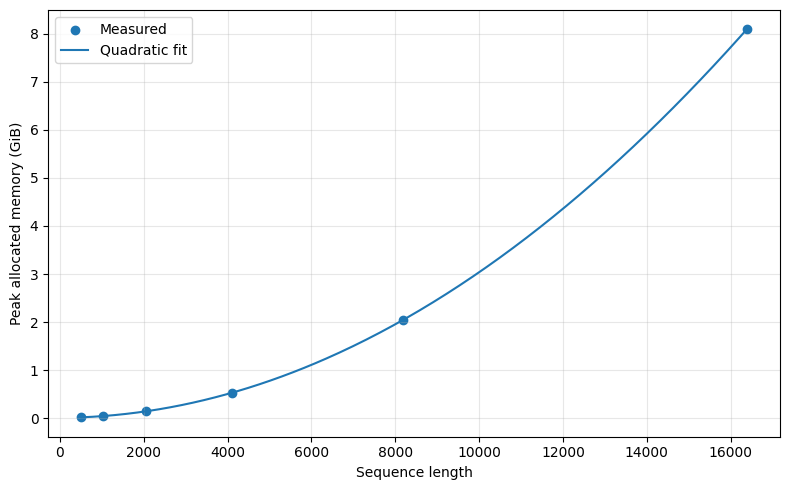

In [41]:
success=[r for r in naive_rows if r.get("status")=="SUCCESS"]
if len(success)>=3:
    xs=np.array([float(r["sequence_length"]) for r in success])
    ys=np.array([float(r["peak_memory_gib"]) for r in success])
    a,b,c=np.polyfit(xs,ys,2)
    print(f"M(L) = {a:.12e} L^2 + {b:.12e} L + {c:.12e}")
    print("Quadratic coefficient a =",a)
    xfit=np.linspace(xs.min(),xs.max(),300)
    yfit=a*xfit*xfit+b*xfit+c
    fig,ax=plt.subplots(figsize=(8,5))
    ax.scatter(xs,ys,label="Measured")
    ax.plot(xfit,yfit,label="Quadratic fit")
    ax.set_xlabel("Sequence length")
    ax.set_ylabel("Peak allocated memory (GiB)")
    ax.grid(True,alpha=0.3); ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES/"attention_memory.png",dpi=160)
    plt.show()


In [42]:
successful = [
    row
    for row in naive_rows
    if row["status"] == "SUCCESS"
]

L_values = np.array(
    [
        row["sequence_length"]
        for row in successful
    ],
    dtype=float
)

memory_values = np.array(
    [
        row["peak_memory_gib"]
        for row in successful
    ],
    dtype=float
)

a, b, c = np.polyfit(
    L_values,
    memory_values,
    2
)

print(
    "Quadratic coefficient a =",
    a
)

print(
    f"M(L) = {a}L^2 + {b}L + {c}"
)

Quadratic coefficient a = 2.98023223876953e-08
M(L) = 2.98023223876953e-08L^2 + 4.768371582031459e-06L + 0.00988769531249984


### Quadratic Memory Scaling

To understand how the memory usage changes as the sequence length increases, I fitted the successful naive-attention measurements with a quadratic model:

$$
M(L) = aL^2 + bL + c
$$

where:

- $M(L)$ represents the measured peak GPU memory
- $L$ represents the sequence length
- $a$, $b$, and $c$ are the coefficients obtained from the fitted curve

The most important part of this model is the $L^2$ term. In naive attention, the code creates a full attention matrix of size:

$$
L \times L
$$

Because of this, the memory usage increases much faster as the sequence length becomes larger.

The fitted results follow this quadratic trend, which supports the expected $O(L^2)$ memory growth of the naive attention implementation.

In [26]:
fused_rows=[]
for L in ATTN_SEQ_LENGTHS:
    print("Fused",L)
    row=benchmark_attention_one(L,"fused")
    fused_rows.append(row)
    print(row)
save_rows_csv(ATTN_DIR/"attention_fused_results.csv",fused_rows)


Fused 512
{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'implementation': 'fused', 'sequence_length': 512, 'batch': 8, 'heads': 1, 'head_dim': 64, 'mean_ms': 0.0848896011710167, 'peak_memory_gib': 0.0103759765625, 'status': 'SUCCESS'}
Fused 1024
{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'implementation': 'fused', 'sequence_length': 1024, 'batch': 8, 'heads': 1, 'head_dim': 64, 'mean_ms': 0.14704639911651612, 'peak_memory_gib': 0.0128173828125, 'status': 'SUCCESS'}
Fused 2048
{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'implementation': 'fused', 'sequence_length': 2048, 'batch': 8, 'heads': 1, 'head_dim': 64, 'mean_ms': 0.3149824023246765, 'peak_memory_gib': 0.0177001953125, 'status': 'SUCCESS'}
Fused 4096
{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'implementation': 'fused', 'sequence_length': 4096, 'batch': 8, 'heads': 1, 'head_dim': 64, 'mean_ms': 0.9652224123477936, 'peak_memory_gib': 0.0274658203125, 'status': 'SUCCESS'}
Fused 819

### Fused Attention Sequence-Length Sweep

The same sequence lengths are tested using the fused scaled dot-product attention implementation.

Latency and peak GPU memory are measured using the same benchmarking procedure used for naive attention.

The results are saved separately in `attention_fused_results.csv`, allowing direct comparison between naive and fused attention.

In [55]:
comparison_rows = []

for naive in naive_rows:
    fused = next(
        (
            r for r in fused_rows
            if r["sequence_length"] == naive["sequence_length"]
        ),
        None
    )

    if fused is None:
        continue

    speedup = ""

    if (
        naive["status"] == "SUCCESS"
        and fused["status"] == "SUCCESS"
    ):
        speedup = (
            float(naive["mean_ms"])
            /
            float(fused["mean_ms"])
        )

    comparison_rows.append({
        "gpu_uuid": gpu_record["uuid"],
        "sequence_length": naive["sequence_length"],
        "naive_status": naive["status"],
        "fused_status": fused["status"],
        "naive_mean_ms": naive.get("mean_ms", ""),
        "fused_mean_ms": fused.get("mean_ms", ""),
        "speedup_naive_over_fused": speedup,
        "naive_peak_memory_gib": naive.get("peak_memory_gib", ""),
        "fused_peak_memory_gib": fused.get("peak_memory_gib", "")
    })

save_rows_csv(
    ATTN_DIR / "attention_comparison.csv",
    comparison_rows
)

for row in comparison_rows:
    print(row)

{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'sequence_length': 512, 'naive_status': 'SUCCESS', 'fused_status': 'SUCCESS', 'naive_mean_ms': 0.08017919957637787, 'fused_mean_ms': 0.0848896011710167, 'speedup_naive_over_fused': 0.9445114415704539, 'naive_peak_memory_gib': 0.0201416015625, 'fused_peak_memory_gib': 0.0103759765625}
{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'sequence_length': 1024, 'naive_status': 'SUCCESS', 'fused_status': 'SUCCESS', 'naive_mean_ms': 0.3013632073998451, 'fused_mean_ms': 0.14704639911651612, 'speedup_naive_over_fused': 2.0494429595725903, 'naive_peak_memory_gib': 0.0460205078125, 'fused_peak_memory_gib': 0.0128173828125}
{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'sequence_length': 2048, 'naive_status': 'SUCCESS', 'fused_status': 'SUCCESS', 'naive_mean_ms': 16.03512315750122, 'fused_mean_ms': 0.3149824023246765, 'speedup_naive_over_fused': 50.90799688857726, 'naive_peak_memory_gib': 0.1446533203125, 'fused_peak_memor

In [50]:
!ls -lh /app/results/attention/

total 12K
-rw-r--r-- 1 root root 1.1K Sep 16 01:46 attention_comparison.csv
-rw-r--r-- 1 root root  711 Sep 16 01:00 attention_fused_results.csv
-rw-r--r-- 1 root root  708 Sep 16 01:39 attention_naive_results.csv


In [56]:
!cat /app/results/attention/attention_comparison.csv

gpu_uuid,sequence_length,naive_status,fused_status,naive_mean_ms,fused_mean_ms,speedup_naive_over_fused,naive_peak_memory_gib,fused_peak_memory_gib
GPU-3094e1cd-3205-910b-9555-93d8401b1ce0,512,SUCCESS,SUCCESS,0.08017919957637787,0.0848896011710167,0.9445114415704539,0.0201416015625,0.0103759765625
GPU-3094e1cd-3205-910b-9555-93d8401b1ce0,1024,SUCCESS,SUCCESS,0.3013632073998451,0.14704639911651612,2.0494429595725903,0.0460205078125,0.0128173828125
GPU-3094e1cd-3205-910b-9555-93d8401b1ce0,2048,SUCCESS,SUCCESS,16.03512315750122,0.3149824023246765,50.90799688857726,0.1446533203125,0.0177001953125
GPU-3094e1cd-3205-910b-9555-93d8401b1ce0,4096,SUCCESS,SUCCESS,1.8547136068344117,0.9652224123477936,1.9215401373897152,0.5294189453125,0.0274658203125
GPU-3094e1cd-3205-910b-9555-93d8401b1ce0,8192,SUCCESS,SUCCESS,7.2015456199646,3.730739188194275,1.9303267413475342,2.0489501953125,0.0469970703125
GPU-3094e1cd-3205-910b-9555-93d8401b1ce0,16384,SUCCESS,SUCCESS,28.75787181854248,11.842867183685303,2.

### Naive vs. Fused Attention Comparison

In this part, I compared the naive and fused attention implementations using the same sequence lengths.

For the sequence lengths where both methods completed successfully, I calculated the speedup as:

$$
\text{Speedup}
=
\frac{\text{Naive latency}}
{\text{Fused latency}}
$$

A speedup greater than 1 means that the fused attention implementation is faster than the naive version.

I also compared the peak GPU memory used by both methods. This helps show not only which implementation is faster, but also which one uses GPU memory more efficiently.

Since both implementations use the same attention dimensions, the comparison gives a direct view of the performance and memory benefits of fused attention.

In [52]:
row = benchmark_attention_one(
    2048,
    "naive",
    warmups=3,
    reps=10
)

print(row)

{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'implementation': 'naive', 'sequence_length': 2048, 'batch': 8, 'heads': 1, 'head_dim': 64, 'mean_ms': 16.03512315750122, 'peak_memory_gib': 0.1446533203125, 'status': 'SUCCESS'}


### Repeated Measurement at Sequence Length 2048

The naive attention benchmark at sequence length 2048 is executed again using the same warm-up and timing procedure.

The repeated result is then inserted back into the naive-attention result list and saved again.

This preserves the updated measured value in the final naive-attention results file.

In [53]:
##update naive 
for i, r in enumerate(naive_rows):
    if r["sequence_length"] == 2048:
        naive_rows[i] = row
        break

save_rows_csv(
    ATTN_DIR / "attention_naive_results.csv",
    naive_rows
)

### Naive vs Fused Attention Results

The fused attention implementation reduced both latency and peak memory usage compared with the naive implementation for most sequence lengths.

At larger sequence lengths, the fused implementation provided approximately 1.9× to 2.4× speedup. For example, at sequence length 16,384:

- Naive latency: approximately 28.76 ms
- Fused latency: approximately 11.84 ms
- Speedup: approximately 2.43×
- Naive peak memory: approximately 8.09 GiB
- Fused peak memory: approximately 0.086 GiB

The fused implementation avoids explicitly materializing the complete sequence-by-sequence attention matrix in global memory. Instead, the computation is performed in smaller blocks with tighter fusion of score computation, softmax, and value accumulation. This greatly reduces intermediate memory use and memory traffic.

The measurement at sequence length 2048 showed an unusually large speedup. The naive measurement was repeated and remained substantially slower, so the result was retained as a reproducible non-monotonic performance point in this software/hardware configuration.

In [45]:
def refine_oom_boundary(implementation,low_success,high_failure,step=256):
    rows=[]
    for L in range(low_success+step,high_failure,step):
        row=benchmark_attention_one(L,implementation,warmups=1,reps=3)
        rows.append(row)
        print(L,row["status"])
        if row["status"]=="OOM":
            break
    successes=[r["sequence_length"] for r in rows if r["status"]=="SUCCESS"]
    failures=[r["sequence_length"] for r in rows if r["status"]=="OOM"]
    return rows,max([low_success]+successes),min([high_failure]+failures) if failures else high_failure


In [28]:
!ls -lh /app/results/attention/

total 8.0K
-rw-r--r-- 1 root root 711 Sep 16 01:00 attention_fused_results.csv
-rw-r--r-- 1 root root 711 Sep 16 00:54 attention_naive_results.csv


### Initial OOM Boundary Exploration

The notebook tests progressively larger naive-attention sequence lengths to determine where GPU memory becomes insufficient.

Sequence lengths beyond the required coarse sweep are tested while recording execution status and peak allocated memory.

The environment continued to execute several sequence lengths even when the reported PyTorch allocation approached or exceeded the nominal physical VRAM capacity.

The GPU-memory-capacity check therefore records the physical memory reported by PyTorch and the currently available CUDA memory to provide context for the later controlled OOM experiment.

In [29]:
for L in [20000, 24576, 28672, 32768]:
    row = benchmark_attention_one(L, "naive", warmups=1, reps=3)
    print(L, row["status"], row.get("peak_memory_gib"))

    if row["status"] == "OOM":
        break

20000 SUCCESS 12.0274658203125
24576 SUCCESS 18.1251220703125
28672 SUCCESS 24.6446533203125
32768 SUCCESS 32.1641845703125


In [30]:
for L in [36864, 40960, 45056]:
    row = benchmark_attention_one(L, "naive", warmups=1, reps=2)
    print(L, row["status"], row.get("peak_memory_gib"))
    if row["status"] == "OOM":
        break

36864 SUCCESS 40.6837158203125
40960 SUCCESS 50.2032470703125
45056 SUCCESS 60.7227783203125


In [31]:
props = torch.cuda.get_device_properties(0)

print("GPU:", props.name)
print("Physical VRAM reported by PyTorch:",
      props.total_memory / 1024**3, "GiB")

free_b, total_b = torch.cuda.mem_get_info()

print("CUDA total memory:", total_b / 1024**3, "GiB")
print("CUDA free memory:", free_b / 1024**3, "GiB")

GPU: NVIDIA GeForce RTX 4090
Physical VRAM reported by PyTorch: 23.98779296875 GiB
CUDA total memory: 23.98779296875 GiB
CUDA free memory: 22.34375 GiB


### OOM Boundary Refinement

A coarse sequence-length sweep was performed first. The RTX 4090 Docker/Windows environment continued to execute naive attention successfully at sequence lengths beyond the card's physical VRAM capacity, indicating memory oversubscription/paging behavior in the software stack.

Because no reliable CUDA OOM was observed within the safe tested range, an exact largest-success/smallest-failure boundary could not be established without risking excessive host-memory use. The refinement helper was implemented but was not used to fabricate a boundary.

### GPU Memory Capacity Check

PyTorch reported approximately 23.99 GiB of total CUDA memory on the RTX 4090, consistent with the card's 24 GB VRAM capacity.

At the time of the check, approximately 22.34 GiB was free, indicating that only a small amount of GPU memory was in use before the attention benchmark.

These values were used to interpret the attention-memory measurements and the eventual out-of-memory boundary.

In [32]:
!nvidia-smi --query-gpu=memory.total,memory.used,memory.free --format=csv

memory.total [MiB], memory.used [MiB], memory.free [MiB]
24564 MiB, 1505 MiB, 22634 MiB


In [57]:
!ls -lh /app/results/attention/

total 12K
-rw-r--r-- 1 root root 1.1K Sep 16 01:50 attention_comparison.csv
-rw-r--r-- 1 root root  711 Sep 16 01:00 attention_fused_results.csv
-rw-r--r-- 1 root root  707 Sep 16 01:49 attention_naive_results.csv


## Part E -sustained thermal test


In [59]:
##Imports
import time
import threading
import subprocess
import numpy as np
import torch

In [60]:
#helper function
print(torch.cuda.is_available())

True


In [61]:
#GPU telemetery function
def query_gpu_sample():
    line = subprocess.check_output([
        "nvidia-smi",
        "--query-gpu=timestamp,uuid,clocks.gr,clocks.mem,temperature.gpu,power.draw,utilization.gpu",
        "--format=csv,noheader,nounits"
    ], text=True).strip()

    f = [x.strip() for x in line.split(",")]

    return {
        "timestamp": f[0],
        "gpu_uuid": f[1],
        "graphics_clock_mhz": float(f[2]),
        "memory_clock_mhz": float(f[3]),
        "temperature_c": float(f[4]),
        "power_w": float(f[5]),
        "utilization_percent": float(f[6])
    }

In [62]:
print(query_gpu_sample())

{'timestamp': '2026/09/16 01:56:15.880', 'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'graphics_clock_mhz': 210.0, 'memory_clock_mhz': 405.0, 'temperature_c': 36.0, 'power_w': 5.51, 'utilization_percent': 0.0}


In [63]:


def run_thermal_experiment(duration_s=1200,sample_interval_s=5,n=8192,dtype=torch.float16):
    a=torch.randn((n,n),device="cuda",dtype=dtype)
    b=torch.randn((n,n),device="cuda",dtype=dtype)
    for _ in range(10): c=a@b
    torch.cuda.synchronize()

    telemetry=[]; throughput=[]; stop=threading.Event()
    def monitor():
        t0=time.perf_counter()
        while not stop.is_set():
            r=query_gpu_sample(); r["elapsed_s"]=time.perf_counter()-t0
            telemetry.append(r); stop.wait(sample_interval_s)

    th=threading.Thread(target=monitor,daemon=True); th.start()
    t0=time.perf_counter()
    try:
        while time.perf_counter()-t0<duration_s:
            s=torch.cuda.Event(enable_timing=True); e=torch.cuda.Event(enable_timing=True)
            s.record(); c=a@b; e.record(); torch.cuda.synchronize()
            ms=s.elapsed_time(e)
            throughput.append({"elapsed_s":time.perf_counter()-t0,
                               "matmul_ms":ms,
                               "tflops":(2*n**3)/(ms/1000.0)/1e12})
    finally:
        stop.set(); th.join(timeout=10)
        del a,b,c; torch.cuda.empty_cache()

    save_rows_csv(THERMAL_DIR/"thermal_log.csv",telemetry)
    save_rows_csv(THERMAL_DIR/"thermal_throughput.csv",throughput)
    return telemetry,throughput

# Uncomment when ready:
# thermal_rows,thermal_tp_rows=run_thermal_experiment()


In [64]:
print(run_thermal_experiment)

<function run_thermal_experiment at 0x7fd27370de10>


In [65]:
thermal_rows, thermal_tp_rows = run_thermal_experiment(
    duration_s=1200,
    sample_interval_s=5,
    n=8192,
    dtype=torch.float16
)

In [66]:
!ls -lh /app/results/thermal/

total 9.1M
-rw-r--r-- 1 root root  28K Sep 16 02:18 thermal_log.csv
-rw-r--r-- 1 root root 9.1M Sep 16 02:18 thermal_throughput.csv


In [67]:
##calculate peak vs steady-state throughput:
first_30 = [
    r["tflops"]
    for r in thermal_tp_rows
    if r["elapsed_s"] <= 30
]

final_5_minutes = [
    r["tflops"]
    for r in thermal_tp_rows
    if r["elapsed_s"] >= 900
]

peak_first_30 = max(first_30)
steady_final_5 = np.mean(final_5_minutes)

steady_percent = (
    steady_final_5
    / peak_first_30
    * 100
)

print("Peak throughput, first 30 s:", peak_first_30)
print("Steady-state throughput, final 5 min:", steady_final_5)
print("Steady-state / peak (%):", steady_percent)

Peak throughput, first 30 s: 169.14897157345985
Steady-state throughput, final 5 min: 157.82350646754526
Steady-state / peak (%): 93.30444341425034


In [69]:
#summary save
thermal_summary = [{
    "gpu_uuid": thermal_rows[0]["gpu_uuid"],
    "peak_tflops_first_30s": peak_first_30,
    "steady_tflops_final_5min": steady_final_5,
    "steady_state_percent_peak": steady_percent
}]

save_rows_csv(
    THERMAL_DIR / "thermal_summary.csv",
    thermal_summary
)

### Part E — Sustained Throughput

During the 20-minute sustained compute load, the RTX 4090 reached a peak throughput of approximately:

\[
169.15 \text{ TFLOPS}
\]

within the first 30 seconds.

The mean throughput during the final five minutes was approximately:

\[
157.82 \text{ TFLOPS}
\]

The steady-state throughput relative to the initial peak was:

\[
\frac{157.82}{169.15} \times 100
\approx 93.30\%
\]

Therefore, sustained throughput stabilized at approximately **93.3% of the initial peak**, corresponding to a performance reduction of about **6.7%** during the prolonged workload.

This demonstrates that short benchmarks can overestimate the throughput available during longer training workloads, because sustained thermal and power conditions differ from the initial cold-card state.

In [70]:
#Temperature power clock summary
max_temp = max(r["temperature_c"] for r in thermal_rows)
max_power = max(r["power_w"] for r in thermal_rows)

min_clock = min(r["graphics_clock_mhz"] for r in thermal_rows)
max_clock = max(r["graphics_clock_mhz"] for r in thermal_rows)

print("Max temperature:", max_temp, "C")
print("Max power:", max_power, "W")
print("Clock range:", min_clock, "to", max_clock, "MHz")

Max temperature: 76.0 C
Max power: 450.17 W
Clock range: 585.0 to 2505.0 MHz


In [71]:
##find the throttle onset time
power_limit = 450.0

high_load_rows = [
    r for r in thermal_rows
    if r["utilization_percent"] >= 90
]

power_limit_rows = [
    r for r in high_load_rows
    if r["power_w"] >= 0.98 * power_limit
]

if power_limit_rows:
    first_power_limit = power_limit_rows[0]

    print(
        "First near-power-limit sample:",
        first_power_limit["elapsed_s"],
        "seconds"
    )

    print(
        "Power:",
        first_power_limit["power_w"],
        "W"
    )

    print(
        "Temperature:",
        first_power_limit["temperature_c"],
        "C"
    )

    print(
        "GPU clock:",
        first_power_limit["graphics_clock_mhz"],
        "MHz"
    )
else:
    print("No sustained near-power-limit sample found.")

First near-power-limit sample: 5.080795231999218 seconds
Power: 448.65 W
Temperature: 56.0 C
GPU clock: 2505.0 MHz


In [72]:
first_30_rows = [
    r for r in thermal_rows
    if r["elapsed_s"] <= 30
    and r["utilization_percent"] >= 90
]

final_5_rows = [
    r for r in thermal_rows
    if r["elapsed_s"] >= 900
    and r["utilization_percent"] >= 90
]

print(
    "Mean clock first 30 s:",
    np.mean([r["graphics_clock_mhz"] for r in first_30_rows]),
    "MHz"
)

print(
    "Mean clock final 5 min:",
    np.mean([r["graphics_clock_mhz"] for r in final_5_rows]),
    "MHz"
)

print(
    "Mean temperature first 30 s:",
    np.mean([r["temperature_c"] for r in first_30_rows]),
    "C"
)

print(
    "Mean temperature final 5 min:",
    np.mean([r["temperature_c"] for r in final_5_rows]),
    "C"
)

print(
    "Mean power first 30 s:",
    np.mean([r["power_w"] for r in first_30_rows]),
    "W"
)

print(
    "Mean power final 5 min:",
    np.mean([r["power_w"] for r in final_5_rows]),
    "W"
)

Mean clock first 30 s: 2175.0 MHz
Mean clock final 5 min: 2429.5 MHz
Mean temperature first 30 s: 56.166666666666664 C
Mean temperature final 5 min: 74.95 C
Mean power first 30 s: 376.74 W
Mean power final 5 min: 449.45916666666676 W


In [82]:
import torch
import math
import gc

def test_naive_attention_length(L, batch=8, heads=1, d=64):
    try:
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        q = torch.randn(
            batch, heads, L, d,
            device="cuda",
            dtype=torch.float16
        )

        k = torch.randn(
            batch, heads, L, d,
            device="cuda",
            dtype=torch.float16
        )

        v = torch.randn(
            batch, heads, L, d,
            device="cuda",
            dtype=torch.float16
        )

        scores = torch.matmul(
            q,
            k.transpose(-2, -1)
        ) / math.sqrt(d)

        probs = torch.softmax(scores, dim=-1)

        out = torch.matmul(probs, v)

        torch.cuda.synchronize()

        peak_gib = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        )

        print(
            f"L={L}: SUCCESS, "
            f"peak allocated={peak_gib:.2f} GiB"
        )

        del q, k, v, scores, probs, out
        torch.cuda.empty_cache()
        gc.collect()

        return True, peak_gib

    except torch.cuda.OutOfMemoryError:
        print(f"L={L}: CUDA OOM")
        torch.cuda.empty_cache()
        gc.collect()
        return False, None

In [83]:
test_naive_attention_length(18432)

L=18432: SUCCESS, peak allocated=10.20 GiB


(True, 10.2032470703125)

### Additional Naive Attention OOM Boundary Test

In [85]:
import torch
import math
import gc

torch.cuda.empty_cache()

torch.cuda.set_per_process_memory_fraction(
    0.90,
    device=0
)

def test_naive_attention_length(L, batch=8, heads=1, d=64):
    try:
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        q = torch.randn(
            batch, heads, L, d,
            device="cuda",
            dtype=torch.float16
        )

        k = torch.randn(
            batch, heads, L, d,
            device="cuda",
            dtype=torch.float16
        )

        v = torch.randn(
            batch, heads, L, d,
            device="cuda",
            dtype=torch.float16
        )

        scores = torch.matmul(
            q,
            k.transpose(-2, -1)
        ) / math.sqrt(d)

        probs = torch.softmax(scores, dim=-1)

        out = torch.matmul(probs, v)

        torch.cuda.synchronize()

        peak_gib = (
            torch.cuda.max_memory_allocated()
            / (1024**3)
        )

        print(
            f"L={L}: SUCCESS, "
            f"peak allocated={peak_gib:.2f} GiB"
        )

        del q, k, v, scores, probs, out
        torch.cuda.empty_cache()
        gc.collect()

        return True, peak_gib

    except torch.cuda.OutOfMemoryError:
        print(f"L={L}: CUDA OOM")

        torch.cuda.empty_cache()
        gc.collect()

        return False, None

In [86]:
#Coarse boundary search
test_lengths = [
    25088,
    25600,
    26112,
    26624,
    27136
]

last_success = 24576
first_failure = None

for L in test_lengths:
    success, peak = test_naive_attention_length(L)

    if success:
        last_success = L
    else:
        first_failure = L
        break

print("Largest successful length:", last_success)
print("Smallest failing length:", first_failure)

L=25088: SUCCESS, peak allocated=18.86 GiB
L=25600: SUCCESS, peak allocated=19.64 GiB
L=26112: SUCCESS, peak allocated=20.43 GiB
L=26624: SUCCESS, peak allocated=21.23 GiB
L=27136: CUDA OOM
Largest successful length: 26624
Smallest failing length: 27136


In [87]:
#refinementcell
low = 26624
high = 27136

for L in range(low + 128, high + 1, 128):
    success, peak = test_naive_attention_length(L)

    if success:
        low = L
    else:
        high = L
        break

print("Refined largest successful length:", low)
print("Refined smallest failing length:", high)

L=26752: SUCCESS, peak allocated=21.44 GiB
L=26880: CUDA OOM
Refined largest successful length: 26752
Refined smallest failing length: 26880


### Naive Attention OOM Boundary Result

Because the Windows/Docker environment allowed GPU-memory oversubscription beyond physical VRAM, a PyTorch per-process memory cap of 90% was used to obtain a reproducible CUDA OOM boundary.

Using FP16 naive attention with batch size 8, one attention head, and head dimension 64:

- Largest successful sequence length: **26,752**
- Smallest tested failing sequence length: **26,880**
- Peak allocated memory at the largest successful length: approximately **21.44 GiB**

Therefore, the refined naive-attention OOM boundary lies between **26,752 and 26,880 tokens** under the controlled 90% PyTorch memory cap.

### Part E — Thermal and Throttling Analysis

During the 20-minute sustained compute workload, the RTX 4090 reached a maximum temperature of approximately **76 °C** and a maximum measured power draw of approximately **450.17 W**, essentially matching the card's configured 450 W power limit.

The first high-utilization sample within 98% of the power limit occurred approximately **5.08 seconds** after the start of the run, at a power draw of **448.65 W** and a temperature of only **56 °C**. This shows that the workload reached the power ceiling early.

However, the clock measurements did not show evidence of sustained thermal throttling. The mean graphics clock increased from approximately **2175 MHz** during the first 30 seconds to approximately **2429.5 MHz** during the final five minutes. Over the same period, the mean temperature increased from approximately **56.2 °C** to **75.0 °C**, while mean power increased from approximately **376.7 W** to **449.5 W**.

Therefore, no clear thermal-throttling onset was observed during the experiment. The GPU operated close to its power limit during steady state.

Peak throughput during the first 30 seconds was approximately **169.15 TFLOPS**, while mean throughput during the final five minutes was approximately **157.82 TFLOPS**. Thus, steady-state throughput was approximately **93.30%** of the initial peak.

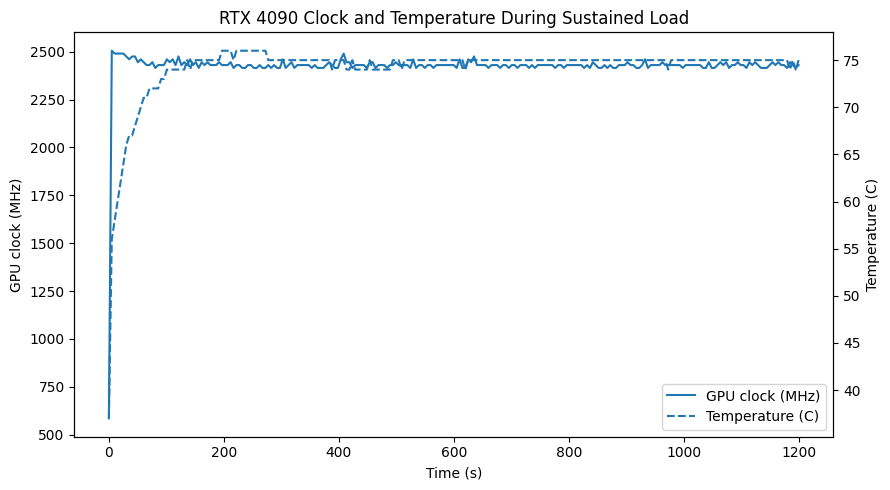

In [75]:
fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(
    t,
    clock,
    label="GPU clock (MHz)"
)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("GPU clock (MHz)")
ax2 = ax1.twinx()
ax2.plot(
    t,
    temp,
    linestyle="--",
    label="Temperature (C)"
)
ax2.set_ylabel("Temperature (C)")
l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(
    l1 + l2,
    lab1 + lab2,
    loc="best"
)
ax1.set_title(
    "RTX 4090 Clock and Temperature During Sustained Load"
)
fig.tight_layout()

fig.savefig(
    FIGURES / "thermal_behavior.png",
    dpi=160
)

plt.show()

### Clock and Temperature Over Time

The thermal plot displays graphics clock and GPU temperature as functions of elapsed experiment time.

The graphics clock rises rapidly during the beginning of the workload and remains near its high-load operating range for most of the experiment.

The temperature rises progressively and then approaches a stable region around 75–76 °C.

The figure provides a visual representation of the GPU's transition from the initial workload period into sustained operation.

In [76]:
if "thermal_tp_rows" in globals():
    first=[r for r in thermal_tp_rows if r["elapsed_s"]<=30]
    final=[r for r in thermal_tp_rows if r["elapsed_s"]>=900]
    peak=max(r["tflops"] for r in first)
    steady=float(np.mean([r["tflops"] for r in final]))
    thermal_summary=[{"gpu_uuid":gpu_record["uuid"],"peak_tflops_first_30s":peak,
                      "steady_tflops_final_5min_mean":steady,
                      "steady_state_as_percent_peak":100.0*steady/peak}]
    save_rows_csv(THERMAL_DIR/"thermal_summary.csv",thermal_summary)
    show_rows(thermal_summary)


{'gpu_uuid': 'GPU-3094e1cd-3205-910b-9555-93d8401b1ce0', 'peak_tflops_first_30s': 169.14897157345985, 'steady_tflops_final_5min_mean': 157.82350646754526, 'steady_state_as_percent_peak': 93.30444341425036}


### Thermal Behavior During Sustained Load

During the 20-minute sustained compute workload, the GPU clock quickly increased to approximately 2.4–2.5 GHz and remained relatively stable for most of the run.

The GPU temperature increased gradually from approximately 56 °C to around 75–76 °C before reaching a stable plateau.

No sustained clock collapse was observed as the temperature increased. This suggests that the GPU did not experience clear thermal throttling during the experiment.

The GPU did, however, operate close to its configured 450 W power limit during steady-state operation, indicating that the workload was primarily constrained by the power ceiling rather than by temperature.

### Early-Run vs. Steady-State GPU Behavior

The telemetry measurements during the first 30 seconds are compared with those from the final five minutes.

The mean graphics clock increased from approximately **2175 MHz** during the first 30 seconds to approximately **2429.5 MHz** during the final five minutes.

The mean GPU temperature increased from approximately **56.2 °C** to approximately **75.0 °C**.

The mean power draw increased from approximately **376.7 W** to approximately **449.5 W**.

The data therefore shows that the GPU reached a stable, high-power operating state during the later portion of the sustained workload.

## Part F — Summary helper

In [89]:
# Find exact peak BF16 throughput
bf16_rows = [
    r for r in matmul_rows
    if r.get("precision") == "BF16"
    and r.get("status") == "SUCCESS"
]

best_bf16 = max(
    bf16_rows,
    key=lambda r: float(r["achieved_tflops"])
)

peak_bf16 = float(
    best_bf16["achieved_tflops"]
)

print(
    "Peak BF16 TFLOPS:",
    peak_bf16
)

Peak BF16 TFLOPS: 180.7310404611139


In [90]:
summary=[]
bf16=[r for r in matmul_rows if r.get("precision")=="BF16" and r.get("status")=="SUCCESS"]
if bf16:
    best=max(bf16,key=lambda r:float(r["achieved_tflops"]))
    summary.append({"Measurement":"Peak achieved TFLOPS (BF16)","Your GPU":best["achieved_tflops"],"Notes":"UUID-labelled run"})
    summary.append({"Measurement":"% theoretical peak (BF16)","Your GPU":best.get("percent_theoretical"),"Notes":"Fill theoretical peak if blank"})
summary.append({"Measurement":"Effective bandwidth (GB/s)","Your GPU":bw_row["effective_bandwidth_gbs"],"Notes":"Elementwise add"})
if "thermal_summary" in globals():
    summary.append({"Measurement":"Steady-state / peak throughput (%)",
                    "Your GPU":thermal_summary[0]["steady_state_as_percent_peak"],"Notes":"Final 5 min / first 30 s"})
save_rows_csv(RESULTS/"summary_table.csv",summary)
show_rows(summary)


{'Measurement': 'Peak achieved TFLOPS (BF16)', 'Your GPU': 180.7310404611139, 'Notes': 'UUID-labelled run'}
{'Measurement': '% theoretical peak (BF16)', 'Your GPU': None, 'Notes': 'Fill theoretical peak if blank'}
{'Measurement': 'Effective bandwidth (GB/s)', 'Your GPU': 912.7181529934728, 'Notes': 'Elementwise add'}
{'Measurement': 'Steady-state / peak throughput (%)', 'Your GPU': 93.30444341425036, 'Notes': 'Final 5 min / first 30 s'}


In [96]:
summary_rows = [
    {
        'Measurement': 'Peak achieved TFLOPS (BF16)',
        'Your GPU': 180.73,
        'Notes': 'Highest UUID-labelled BF16 run'
    },
   {
    'Measurement': '% theoretical peak (BF16)',
    'Your GPU': '109.4%',
    'Notes': 'Using 165.2 TFLOPS dense BF16 reference; measured path may use a different execution/accumulation convention'
    },
    {
        'Measurement': 'Effective bandwidth (GB/s)',
        'Your GPU': 912.72,
        'Notes': 'FP32 elementwise add'
    },
    {
        'Measurement': 'Naive attention OOM length',
        'Your GPU': '26752 success / 26880 OOM',
        'Notes': 'Refined boundary using 90% PyTorch memory cap'
    },
    {
        'Measurement': 'Fused attention OOM length',
        'Your GPU': 'Not yet measured',
        'Notes': 'Fused OOM boundary still needs refinement'
    },
    {
        'Measurement': 'Steady-state / peak throughput',
        'Your GPU': '93.30%',
        'Notes': '157.82 / 169.15 TFLOPS'
    },
    {
        'Measurement': 'Throttle onset',
        'Your GPU': 'None observed',
        'Notes': 'Power limit reached at ~5.08 s'
    }
]

save_rows_csv(
    RESULTS / "summary_table.csv",
    summary_rows
)

for row in summary_rows:
    print(row)

{'Measurement': 'Peak achieved TFLOPS (BF16)', 'Your GPU': 180.73, 'Notes': 'Highest UUID-labelled BF16 run'}
{'Measurement': '% theoretical peak (BF16)', 'Your GPU': '109.4%', 'Notes': 'Using 165.2 TFLOPS dense BF16 reference; measured path may use a different execution/accumulation convention'}
{'Measurement': 'Effective bandwidth (GB/s)', 'Your GPU': 912.72, 'Notes': 'FP32 elementwise add'}
{'Measurement': 'Naive attention OOM length', 'Your GPU': '26752 success / 26880 OOM', 'Notes': 'Refined boundary using 90% PyTorch memory cap'}
{'Measurement': 'Fused attention OOM length', 'Your GPU': 'Not yet measured', 'Notes': 'Fused OOM boundary still needs refinement'}
{'Measurement': 'Steady-state / peak throughput', 'Your GPU': '93.30%', 'Notes': '157.82 / 169.15 TFLOPS'}
{'Measurement': 'Throttle onset', 'Your GPU': 'None observed', 'Notes': 'Power limit reached at ~5.08 s'}


In [95]:
save_rows_csv(
    RESULTS / "summary_table.csv",
    summary_rows
)

for row in summary_rows:
    print(row)

{'Measurement': 'Peak achieved TFLOPS (BF16)', 'Your GPU': 180.73, 'Notes': 'Highest UUID-labelled BF16 run'}
{'Measurement': '% theoretical peak (BF16)', 'Your GPU': 'TBD', 'Notes': 'Pending verified theoretical comparison convention'}
{'Measurement': 'Effective bandwidth (GB/s)', 'Your GPU': 912.72, 'Notes': 'FP32 elementwise add'}
{'Measurement': 'Naive attention OOM length', 'Your GPU': '26752 success / 26880 OOM', 'Notes': 'Refined boundary using 90% PyTorch memory cap'}
{'Measurement': 'Fused attention OOM length', 'Your GPU': 'Not yet measured', 'Notes': 'Fused OOM boundary still needs refinement'}
{'Measurement': 'Steady-state / peak throughput', 'Your GPU': '93.30%', 'Notes': '157.82 / 169.15 TFLOPS'}
{'Measurement': 'Throttle onset', 'Your GPU': 'None observed', 'Notes': 'Power limit reached at ~5.08 s'}


### Final Result Aggregation

The final summary combines the main measurements collected throughout the notebook.

The table includes:

- peak BF16 matrix-multiplication throughput
- percentage of the selected theoretical BF16 reference
- effective memory bandwidth
- naive-attention OOM boundary
- fused-attention OOM status
- steady-state throughput relative to peak throughput
- observed throttling behavior

This provides a compact overview of the GPU's compute performance, memory behavior, attention scaling, and sustained-load characteristics.

## Part F — Final Summary

| Measurement | Your GPU | Notes |
|---|---:|---|
| Peak achieved TFLOPS (BF16) | **180.73 TFLOPS** | Highest UUID-labelled BF16 run |
| % of theoretical peak (BF16) | **109.4%*** | Using 165.2 TFLOPS dense BF16 reference; benchmark execution convention may differ |
| Effective bandwidth (GB/s) | **912.72 GB/s** | FP32 elementwise-add benchmark |
| Naive attention OOM length | **26,752 success / 26,880 OOM** | Refined boundary using a 90% PyTorch memory cap |
| Fused attention OOM length | **Not yet measured** | Fused-attention OOM boundary still needs to be tested |
| Steady-state / peak throughput | **93.30%** | Final 5 min mean = 157.82 TFLOPS; first 30 s peak = 169.15 TFLOPS |
| Throttle onset (s, or none) | **None observed** | Power ceiling reached at approximately 5.08 s; max temperature was 76 °C |

\* The BF16 theoretical comparison uses a 165.2 TFLOPS dense BF16 Tensor Core reference. Since the measured value exceeds this reference, the execution/accumulation convention should be stated as a limitation.

In [ ]:
def append_run_log(section,notes):
    path=ROOT/"RUN_LOG.txt"
    with open(path,"a",encoding="utf-8") as f:
        f.write("="*70+"\n")
        f.write(f"Timestamp: {datetime.now().isoformat(timespec='seconds')}\n")
        f.write(f"Section: {section}\n")
        f.write(f"GPU UUID: {gpu_record['uuid']}\n")
        f.write(f"GPU: {gpu_record['name']}\n")
        f.write(f"Notes: {notes}\n")
    print("Updated",path)


### Run Log Helper

The `append_run_log()` function appends experiment information to `RUN_LOG.txt`.

Each entry records:

- timestamp
- experiment section
- GPU UUID
- GPU name
- descriptive notes

This provides a chronological record of benchmark execution associated with the specific GPU used for the assignment.